# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [15]:
from google.colab import files
uploaded = files.upload()  # upload data.csv when prompted


Saving cirrhosis.csv to cirrhosis (2).csv
Saving data.csv to data (2).csv


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.


Linear models assume an unbounded, continuous outcome. Many real outcomes,
probabilities, counts, class labels, don't fit that. GLMs apply a transformation (via an activation function like sigmoid) to map a linear combination of features to the appropriate output space, giving flexibility while keeping a linear structure underneath.

Cross entropy is derived directly from the log-likelihood of the Bernoulli/categorical distribution, so minimizing it is equivalent to maximum likelihood estimation. It also heavly penalizes confident wrong predictions, pushing the model toward well-calibrated probabilities.

Partially true. The latent variable (log-odds) is linear in the features, but the predicted probability is nonlinear due to the sigmoid. It's best described as a generalized linear model.

False. You apply a threshold to the predicted probabilities to get class labels. It's one of the most common classifiers.

No. Coeficients represent the change in log-odds per unit change in a feature. The effect on predicted probability is nonlinear and varies by observation.

False. The log-odds is still linear in the features, so interactions and nonlinear covariate effects must still be encoded manually.

False. Logistic regression is appropriate for categorical outcomes; OLS is appropriate for continuous ones. Neither is universally superior.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [17]:
df = pd.read_csv('data.csv', sep=';')
cols = ['Debtor','Tuition fees up to date','Scholarship holder',
        'Age at enrollment','Curricular units 1st sem (approved)','Target']
df = df[cols]

# No missing values
print("Missing values:\n", df.isnull().sum())

# Binary target
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

X = df[['Debtor','Tuition fees up to date','Scholarship holder','Age at enrollment']]
y = df['dropout']

Missing values:
 Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


In [18]:
lr = LogisticRegression()
lr.fit(X, y)
print("\nCoefficients:")
for name, coef in zip(X.columns, lr.coef_[0]):
    print(f"  {name}: {coef:.4f}")


Coefficients:
  Debtor: 0.5306
  Tuition fees up to date: -2.5565
  Scholarship holder: -1.2274
  Age at enrollment: 0.0499


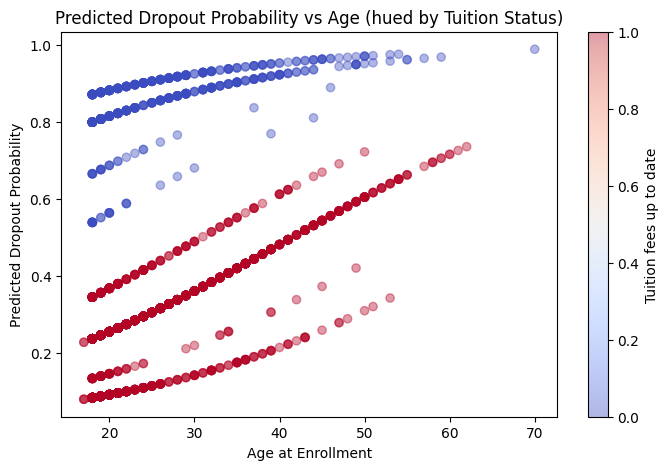


Avg dropout prob (tuition NOT up to date): 0.8607
Avg dropout prob (tuition up to date): 0.2481
Average difference: 0.6126


In [19]:
probs = lr.predict_proba(X)[:,1]

plt.figure(figsize=(8,5))
scatter = plt.scatter(df['Age at enrollment'], probs,
                      c=df['Tuition fees up to date'], cmap='coolwarm', alpha=0.4)
plt.colorbar(scatter, label='Tuition fees up to date')
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.title('Predicted Dropout Probability vs Age (hued by Tuition Status)')
plt.show()

tuition_0 = probs[df['Tuition fees up to date']==0].mean()
tuition_1 = probs[df['Tuition fees up to date']==1].mean()
print(f"\nAvg dropout prob (tuition NOT up to date): {tuition_0:.4f}")
print(f"Avg dropout prob (tuition up to date): {tuition_1:.4f}")
print(f"Average difference: {tuition_0 - tuition_1:.4f}")

In [20]:
preds = lr.predict(X)
cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)
print(f"\nConfusion Matrix:\n{cm}")
print(f"Accuracy: {acc:.4f}")


Confusion Matrix:
[[2841  162]
 [ 891  530]]
Accuracy: 0.7620


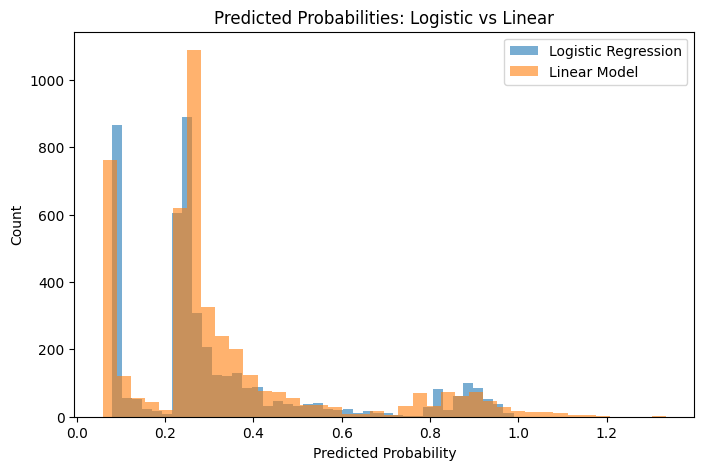


Linear model prob range: [0.0583, 1.3350]
Logistic model prob range: [0.0795, 0.9891]


In [21]:
lm = LinearRegression()
lm.fit(X, y)
lm_probs = lm.predict(X)

plt.figure(figsize=(8,5))
plt.hist(probs, bins=40, alpha=0.6, label='Logistic Regression')
plt.hist(lm_probs, bins=40, alpha=0.6, label='Linear Model')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Predicted Probabilities: Logistic vs Linear')
plt.legend()
plt.show()

print(f"\nLinear model prob range: [{lm_probs.min():.4f}, {lm_probs.max():.4f}]")
print(f"Logistic model prob range: [{probs.min():.4f}, {probs.max():.4f}]")

In [22]:
X2 = df[['Debtor','Tuition fees up to date','Curricular units 1st sem (approved)']]
y2 = df['Target']
mn = LogisticRegression(max_iter=1000)
mn.fit(X2, y2)
preds2 = mn.predict(X2)
cm2 = confusion_matrix(y2, preds2, labels=mn.classes_)
acc2 = accuracy_score(y2, preds2)
print(f"\nMultinomial Confusion Matrix:")
print(f"Classes: {mn.classes_}")
print(cm2)
print(f"Classes in hard predictions: {np.unique(preds2)}")
print(f"Accuracy: {acc2:.4f}")
proba2 = mn.predict_proba(X2)
print(f"\nSample predicted probabilities (first row): {proba2[0].round(4)}")
print(f"Proba classes: {mn.classes_}")


Multinomial Confusion Matrix:
Classes: ['Dropout' 'Enrolled' 'Graduate']
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
Classes in hard predictions: ['Dropout' 'Graduate']
Accuracy: 0.7046

Sample predicted probabilities (first row): [0.6805 0.2105 0.109 ]
Proba classes: ['Dropout' 'Enrolled' 'Graduate']


2. Debtor (0.53) and Age at enrollment (0.05) both have positive coefficients, meaning they're associated with a higher probability of dropping out. Tuition fees up to date (−2.56) and Scholarship holder (−1.23) have negative coefficients, predicting lower dropout probability. Being up to date on tuition is by far the strongest predictor, students who are current on payments are substantially less likely to drop out.
3. The effect of tuition status is large across all ages, but the gap between the two groups appears widest for students in the 20–30 age range where most observations are concentrated. On average, being up to date on tuition reduces predicted dropout probability by about 0.61 (from 0.86 down to 0.25), which is a substantial difference.
4. The model achieves 76.2% accuracy. Looking at the confusion matrix, it correctly identifies most non-dropouts but misclasifies 891 actual dropouts as non-dropouts. The model is somewhat conservative, it underestimates dropout risk for a meaningful portion of at-risk students.
5. The linear model produces predicted probabilities ranging from 0.06 to 1.34, which is invalid since probabilities cannot exceed 1. Logistic regression stays properly bounded between 0.08 and 0.99. For a binary outcome like this, logistic regression is clearly the more appropriate choice.
6. The highest-risk students are those behind on tuition, carrying debt, and without a scholarship,  particularly older enrollees. Possible interventions include automatic financial aid outreach for students falling behind on payments, early-semester advising flags for debtors, and emergency grant programs targeting students with multiple financial risk factors simultaneously.
7. The hard classification never predicts Enrolled, the confusion matrix shows an entire column of zeros for that class. This happens because Enrolled is the smallest class and never rises to the top prediction. However, .predict_proba assigns nonzero probability to all three classes for every observation, so the model recognizes Enrolled as a possibility but never as the most likely outcome.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# Load and filter
df = pd.read_csv('cirrhosis.csv')
cols = ['Bilirubin','Edema','Drug','Stage','Status']
df = df[cols]

# Missing values: Drug and Stage have 106 and 6 missing — drop them
df = df.dropna()
print("Shape after dropping missing:", df.shape)

# Binary target: alive = 1, dead = 0
df['alive'] = (df['Status'] != 'D').astype(int)

# Encode categoricals
df['Edema_S'] = (df['Edema'] == 'S').astype(int)
df['Edema_Y'] = (df['Edema'] == 'Y').astype(int)
df['Drug_bin'] = (df['Drug'] == 'D-penicillamine').astype(int)

X = df[['Edema_S','Edema_Y','Drug_bin','Bilirubin']]
y = df['alive']

Shape after dropping missing: (312, 5)


In [24]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)
print("\nCoefficients:")
for name, coef in zip(X.columns, lr.coef_[0]):
    print(f"  {name}: {coef:.4f}")



Coefficients:
  Edema_S: -0.4515
  Edema_Y: -1.6132
  Drug_bin: -0.2320
  Bilirubin: -0.3514


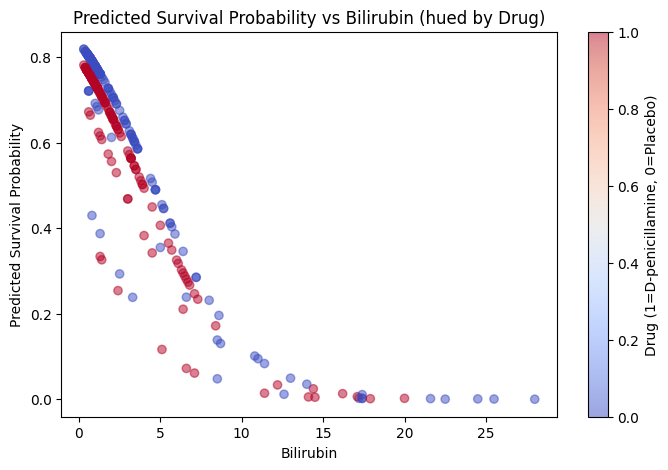


Avg survival prob (placebo): 0.6090
Avg survival prob (drug): 0.5900
Average difference: -0.0190


In [25]:
probs = lr.predict_proba(X)[:,1]

plt.figure(figsize=(8,5))
scatter = plt.scatter(df['Bilirubin'], probs,
                      c=df['Drug_bin'], cmap='coolwarm', alpha=0.5)
plt.colorbar(scatter, label='Drug (1=D-penicillamine, 0=Placebo)')
plt.xlabel('Bilirubin')
plt.ylabel('Predicted Survival Probability')
plt.title('Predicted Survival Probability vs Bilirubin (hued by Drug)')
plt.show()

drug_0 = probs[df['Drug_bin']==0].mean()
drug_1 = probs[df['Drug_bin']==1].mean()
print(f"\nAvg survival prob (placebo): {drug_0:.4f}")
print(f"Avg survival prob (drug): {drug_1:.4f}")
print(f"Average difference: {drug_1 - drug_0:.4f}")

In [26]:
preds = lr.predict(X)
cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)
print(f"\nConfusion Matrix:\n{cm}")
print(f"Accuracy: {acc:.4f}")


Confusion Matrix:
[[ 59  66]
 [ 16 171]]
Accuracy: 0.7372


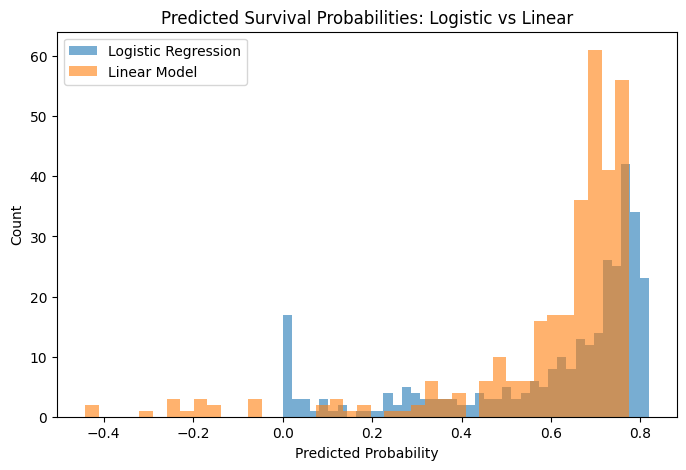


Linear prob range: [-0.4417, 0.7739]
Logistic prob range: [0.0002, 0.8185]


In [27]:
lm = LinearRegression()
lm.fit(X, y)
lm_probs = lm.predict(X)

plt.figure(figsize=(8,5))
plt.hist(probs, bins=40, alpha=0.6, label='Logistic Regression')
plt.hist(lm_probs, bins=40, alpha=0.6, label='Linear Model')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Predicted Survival Probabilities: Logistic vs Linear')
plt.legend()
plt.show()

print(f"\nLinear prob range: [{lm_probs.min():.4f}, {lm_probs.max():.4f}]")
print(f"Logistic prob range: [{probs.min():.4f}, {probs.max():.4f}]")


In [28]:
X2 = df[['Edema_S','Edema_Y','Bilirubin']]
y2 = df['Stage'].astype(str)
mn = LogisticRegression(max_iter=1000)
mn.fit(X2, y2)
preds2 = mn.predict(X2)
cm2 = confusion_matrix(y2, preds2, labels=mn.classes_)
acc2 = accuracy_score(y2, preds2)
print(f"\nStage Confusion Matrix:")
print(f"Classes: {mn.classes_}")
print(cm2)
print(f"Classes in hard predictions: {np.unique(preds2)}")
print(f"Accuracy: {acc2:.4f}")
proba2 = mn.predict_proba(X2)
print(f"Sample predicted probabilities: {proba2[0].round(4)}")
print(f"Proba classes: {mn.classes_}")


Stage Confusion Matrix:
Classes: ['1.0' '2.0' '3.0' '4.0']
[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
Classes in hard predictions: ['3.0' '4.0']
Accuracy: 0.4327
Sample predicted probabilities: [0.     0.0325 0.1436 0.8238]
Proba classes: ['1.0' '2.0' '3.0' '4.0']


2. The drug coefficient is −0.23, meaning D-penicillamine is associated with a slightly lower predicted survival probability compared to placebo,  it does not appear to improve survival. Higher bilirubin (−0.35) predicts lower survival, which makes clinical sense as elevated bilirubin signals worsening liver function. Edema without diuretic response (Edema_Y, −1.61) is strongly associated with lower survival, and even manageable edema (Edema_S, −0.45) reduces survival probability relative to no edema.
3. The average predicted survival probability is 0.609 for placebo patients and 0.590 for drug patients, a difference of only −0.019. The drug provides essentially no meaningful survival benefit on average, and the scatter plot confirms the two groups overlap almost entirely across all bilirubin values.
4. The model achieves 73.7% accuracy. It correctly classifies most survivors but misclassifies 66 surviving patients as dead. The model is reasonably accurate but tends to be somewhat pessimistic about patient outcomes.
5. The linear model produces predicted probabilities ranging from −0.44 to 0.77, with negative values being meaningless. Logistic regression stays bounded between 0.0002 and 0.82. The linear model is unreliable for probability estimation here and logistic regression is clearly more appropriate.
6. The hard classification only predicts Stage 3 or 4, never Stage 1 or 2, with overall accuracy of just 43.3%. However, .predict_proba assigns nonzero probability to all four stages for every patient, the model recognizes all classes probabilistically but never finds stages 1 or 2 to be the most likely outcome, likely because Bilirubin and Edema alone are insufficient to distinguish early-stage disease reliably.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

The coefficients in logistic regression are the weights applied to each feature in the linear combination b·x (the log-odds / latent variable). A positive coefficient means that feature increases the log-odds of the outcome, and a negative coefficient means it decreases it. Their magnitude reflects how strongly each feature shifts the log-odds.

For the linear model ŷ = b·x, the derivative with respect to the k-th feature is simply bₖ. It's constant, for every 1-unit increase in xₖ, the prediction changes by exactly bₖ regardless of where you are.

For the logistic model, applying the chain rule to p̂ = eᴸ/(1+eᴸ) where L = b·x:
∂p̂/∂xₖ = bₖ · (eᴸ/(1+eᴸ)) · (1/(1+eᴸ)) = bₖ · p̂ · (1 − p̂)
Unlike the linear model, this derivative is not constant, it depends on the current value of p̂, which itself depends on x. The effect of xₖ on the predicted probability is largest when p̂ is near 0.5, and shrinks toward zero as p̂ approaches 0 or 1. At p̂ = 0.5, p̂(1−p̂) = 0.25, so bₖ · 0.25 = bₖ/4 is a reasonable approximation of the marginal effect. This is why the hint says "times 4", near p̂ = 0.5, the coefficient itself divided by 4 approximates how much a 1-unit change in xₖ shifts the predicted probability.

Starting from the transformation shown:
log(p̂ / (1−p̂)) = b·x
The left side is the log-odds ratio. Since b·x = b₀ + b₁x₁ + ... + bₖxₖ, a 1-unit increase in xₖ increases the log-odds by exactly bₖ. This is constant and doesn't depend on x, unlike the effect on the predicted probability. This is the cleanest interpretation of logistic regression coefficientd, they are log-odds ratios, not probability changes.